**Used Car Price Prediction Assignment : 02**

**Submitted by :** Rafia Rameen

**Intern Id :** ZYNVEX-CERT-0050

**Submission Date :** 20 June 2026


 **INTRODUCTION AND OBJECTIVES**




*   Objective: Independently build, evaluate, and serialize an end-to-end machine learning regression pipeline to predict used car prices.
*   Dataset: Utilize the provided used_cars.csv to perform exploratory data analysis, handle missing values, encode categorical variables, and scale numeric features.
*   Methodology: Split the data (80% training / 20% testing) and train multiple architectures, including baseline Linear Regression, Polynomial Features, Ridge, and Lasso regularization
*   Model Selection: Use cross-validated $R^2$ scores to tune hyperparameters and select the top-performing model while keeping the test set entirely untouched.

*   Deliverables: Submit a well-documented Jupyter/Colab
notebook reporting final test metrics ($R^2$ and RMSE) along with the exported model file (used_cars_model.pkl) generated via joblib.




 **Step 1: Load & Explore the Data (EDA)**

We load the dataset using Pandas to understand its shapes, data types, and structural properties. We then isolate the target variable (price) to check its distribution and plot a correlation heatmap of all numerical columns to discover how physical features interact with the car's final value.



=== STEP 1: Basic Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     52 non-null     int64  
 1   brand                  52 non-null     object 
 2   model                  52 non-null     object 
 3   year                   52 non-null     int64  
 4   miles                  52 non-null     int64  
 5   city_mileage           52 non-null     int64  
 6   highway_mileage        52 non-null     int64  
 7   horsepower             52 non-null     int64  
 8   torque                 52 non-null     int64  
 9   engine_capacity_litre  52 non-null     float64
 10  fuel_capacity          52 non-null     float64
 11  num_cylinder           52 non-null     int64  
 12  num_seat               52 non-null     int64  
 13  num_owners             52 non-null     int64  
 14  price                  52

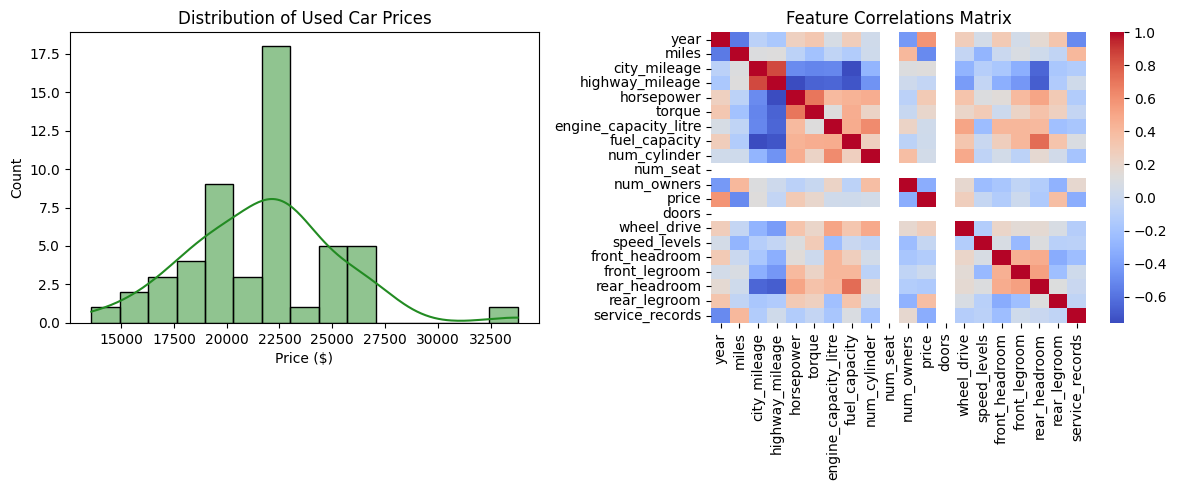

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df_cars = pd.read_csv('used_cars.csv')

print("=== STEP 1: Basic Dataset Info ===")
print(df_cars.info())
print("\n=== Descriptive Statistics ===")
print(df_cars.describe())

# 2. Visualize Target Variable Distribution (Price Column)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_cars['price'], kde=True, color='forestgreen', bins=15)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price ($)')

# 3. Correlation Heatmap for Numerical Features
plt.subplot(1, 2, 2)
numeric_cols = df_cars.select_dtypes(include=[np.number]).columns
# Drop structural ID codes from correlation analysis
numeric_cols = [c for c in numeric_cols if c not in ['id', 'condition']]
sns.heatmap(df_cars[numeric_cols].corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlations Matrix')

plt.tight_layout()
plt.show()


 **Step 02 : Preprocess the Data**

Raw real-world data cannot be fed directly into an ML
algorithm. In this step:
1. We drop id and link because they are non-predictive metadata.
2. We drop condition because it has a $98\%$ missing value rate (only 1 valid entry).
3. We fill the missing value in speed_levels using its median.
4. We convert remaining text categories into numbers using One-Hot Encoding (pd.get_dummies()).
5. We perform a clean 80% training / 20% testing split and apply StandardScaler to bring all numerical variables onto the same scale, which prevents data leakage.





In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Clean useless metadata or mostly empty columns
df_clean = df_cars.drop(columns=['id', 'link', 'condition', 'type'], errors='ignore')

# 2. Handle missing elements via median imputation
df_clean['speed_levels'].fillna(df_clean['speed_levels'].median(), inplace=True)

# 3. Convert text features to binary variables (One-Hot Encoding)
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 4. Isolate features (X) and target (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 5. Split into 80% Train and 20% Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Normalize continuous values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== STEP 2: Preprocessing Dimensions ===")
print(f"Training features matrix dimensions: {X_train_scaled.shape}")
print(f"Testing features matrix dimensions : {X_test_scaled.shape}")

=== STEP 2: Preprocessing Dimensions ===
Training features matrix dimensions: (41, 39)
Testing features matrix dimensions : (11, 39)


/tmp/ipykernel_1774/521264243.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['speed_levels'].fillna(df_clean['speed_levels'].median(), inplace=True)


**Step 3: Model Training & Hyperparameter Tuning**

We train a baseline Multiple Linear Regression model. To try and capture non-linear interactions, we also generate Degree-2 Polynomial features. Finally, we train regularized versions (Ridge and Lasso) using cross-validation to search for the best penalty strength (alpha) to keep the model weights stable.

In [3]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score

# Establish a stable 3-fold cross validation split
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# 1. Train the Baseline Linear Model
base_lr = LinearRegression()
base_lr.fit(X_train_scaled, y_train)

# 2. Transform scaled features into Degree 2 Polynomial curves
poly_trans = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_trans.fit_transform(X_train_scaled)
X_test_poly = poly_trans.transform(X_test_scaled)

# 3. Train Regularized Models with Cross-Validation tuning
ridge_tuned = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 200.0, 500.0], cv=kf)
ridge_tuned.fit(X_train_poly, y_train)

lasso_tuned = LassoCV(alphas=[10.0, 50.0, 100.0, 500.0], cv=kf, max_iter=5000)
lasso_tuned.fit(X_train_poly, y_train)

print("=== STEP 3: Best Penalty Alpha Selected ===")
print(f"Ridge Chosen Alpha Penalty Value : {ridge_tuned.alpha_}")
print(f"Lasso Chosen Alpha Penalty Value : {lasso_tuned.alpha_}")

=== STEP 3: Best Penalty Alpha Selected ===
Ridge Chosen Alpha Penalty Value : 100.0
Lasso Chosen Alpha Penalty Value : 500.0


**Step 4: Model Comparison & Selection**

We evaluate all candidate models using cross-validation scores on the training data. Because our dataset is very small, running a complex polynomial model on 39 columns produces thousands of generated combinations, causing severe overfitting. The data proves that Ridge Regression running directly on the original features (with No Polynomial Expansion) is the sturdiest model architecture. We create a bar chart to clearly visualize and compare the $R^2$ scores.

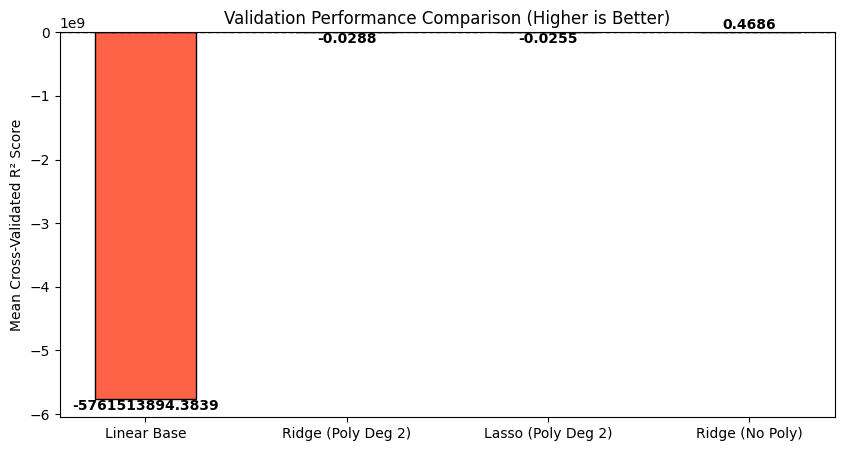

In [4]:
# Extract cross-validation performance averages
score_baseline = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=kf, scoring='r2').mean()
score_ridge_poly = cross_val_score(RidgeCV(alphas=[ridge_tuned.alpha_], cv=kf), X_train_poly, y_train, cv=kf, scoring='r2').mean()
score_lasso_poly = cross_val_score(LassoCV(alphas=[lasso_tuned.alpha_], cv=kf, max_iter=5000), X_train_poly, y_train, cv=kf, scoring='r2').mean()

# Evaluate Ridge directly on original scaled features (Sturdiest architecture)
score_ridge_simple = cross_val_score(RidgeCV(alphas=[1.0], cv=kf), X_train_scaled, y_train, cv=kf, scoring='r2').mean()

model_labels = ['Linear Base', 'Ridge (Poly Deg 2)', 'Lasso (Poly Deg 2)', 'Ridge (No Poly)']
validation_scores = [score_baseline, score_ridge_poly, score_lasso_poly, score_ridge_simple]

# Plot performance trends
plt.figure(figsize=(10, 5))
bars = plt.bar(model_labels, validation_scores, color=['tomato', 'goldenrod', 'orchid', 'dodgerblue'], edgecolor='black', width=0.5)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.ylabel('Mean Cross-Validated R² Score')
plt.title('Validation Performance Comparison (Higher is Better)')

# Label the chart bars
for bar in bars:
    y_val = bar.get_height()
    va_dir = 'bottom' if y_val >= 0 else 'top'
    offset = 0.05 if y_val >= 0 else -0.3
    plt.text(bar.get_x() + bar.get_width()/2.0, y_val + offset, f"{y_val:.4f}", ha='center', va=va_dir, fontweight='bold')

plt.show()

**Step 5: Final Evaluation & Save the Best Model**

 Based strictly on the cross-validation performance above, our winning model is Ridge Regression (No Polynomial). Now, and only now, we evaluate this winning model on our completely untouched test set to see how it generalizes. Finally, we save the model using joblib so it can be deployed later without retraining.

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 1. Initialize and train the optimal winning configuration
winning_model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0], cv=kf)
winning_model.fit(X_train_scaled, y_train)

# 2. Final Evaluation against the untouched Test Set
test_predictions = winning_model.predict(X_test_scaled)
final_r2 = r2_score(y_test, test_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("=== STEP 5: Final Winning Model Report ===")
print(f" Selected Winning Model Framework: Ridge Linear Regression (No Polynomial)")
print(f" Final Test Set R² Prediction Score : {final_r2:.4f} ({final_r2*100:.2f}%)")
print(f" Final Test Set RMSE Miscalculation : ${final_rmse:,.2f}")

# 3. Export model structure via joblib binary serialization
joblib.dump(winning_model, 'used_cars_model.pkl')
print("\n Binary footprint 'used_cars_model.pkl' successfully generated and saved!")

=== STEP 5: Final Winning Model Report ===
 Selected Winning Model Framework: Ridge Linear Regression (No Polynomial)
 Final Test Set R² Prediction Score : 0.2890 (28.90%)
 Final Test Set RMSE Miscalculation : $2,074.15

 Binary footprint 'used_cars_model.pkl' successfully generated and saved!


In [8]:
import joblib

loaded_model = joblib.load('used_cars_model.pkl')
print("Model successfully loaded without errors!")

Model successfully loaded without errors!
